# Conhecendo a base de dados

## Importando os dados


In [102]:
import pandas as pd

In [103]:
dados = 'Aula_4_dados.csv'

dados = pd.read_csv(dados, sep=';')

# A função head() retorna as 5 primeiras linhas do dataframe
display(dados.head(1)) 

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0


In [104]:
# A função .tail() retorna as 5 últimas linhas do dataframe
display(dados.tail(1)) 

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
32959,Conjunto Comercial/Sala,Centro,0,0,0,250,6500.0,4206.0,1109.0


In [105]:
# type() retorna o tipo de dado
type(dados)

pandas.DataFrame

## Características gerais da base de dados

In [106]:
# Explorando a quantidade de linhas e colunas

dados.shape # Retorna a quantidade de linhas e colunas do dataframe.

(32960, 9)

In [107]:
dados.columns # Retorna uma tupla das colunas

Index(['Tipo', 'Bairro', 'Quartos', 'Vagas', 'Suites', 'Area', 'Valor',
       'Condominio', 'IPTU'],
      dtype='str')

In [108]:
dados.info() # Retorna o tipo de dados e outros

<class 'pandas.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  str    
 1   Bairro      32960 non-null  str    
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), str(2)
memory usage: 3.0 MB


In [109]:
# Dados do tipo object são strings
# [ ] retorna dados no formato series

dados['Tipo'].head() # Tipo object são strings 

0                  Quitinete
1                       Casa
2    Conjunto Comercial/Sala
3                Apartamento
4                Apartamento
Name: Tipo, dtype: str

In [110]:
dados[['Quartos','Valor']].head() # Quando adicionamos dois colchetes é possível retornar mais de uma coluna.

,Quartos,Valor
0,1,1700.0
1,2,7000.0
2,0,5200.0
3,1,800.0
4,1,800.0


# Análise exploratória de dados

## Qual o valor médio de aluguel por tipo de imóvel?

In [111]:
dados.groupby('Tipo').mean(numeric_only=True)

,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
Tipo,,,,,,,
Apartamento,2.481569,1.232388,0.875998,119.790498,4744.614648,1722.653697,686.170413
Box/Garagem,0.060976,1.304878,0.000000,17.524390,1899.756098,305.450000,125.846154
Casa,3.133402,1.795243,1.258532,250.578077,6793.454922,931.280952,1582.506394
Casa Comercial,1.562264,2.203774,0.260377,372.241509,14478.264151,1935.709677,1707.386740
Casa de Condomínio,4.007028,3.101406,2.864458,456.161647,11952.061245,1342.025527,3252.517730
Casa de Vila,1.927711,0.389558,0.228916,78.469880,1574.369478,138.768421,183.878788
Chácara,3.000000,0.000000,0.000000,0.000000,4900.000000,NaN,NaN
Conjunto Comercial/Sala,0.040939,2.516801,0.010858,214.472487,14715.045521,4512.218100,1399.596571
Flat,1.415966,0.962185,0.754202,65.483193,4546.189076,2027.720554,493.166667


In [112]:
dados.groupby('Tipo')['Valor'].mean() # O código estando dessa forma ele retorna um series.
dados.groupby('Tipo')[['Valor']].mean() # O código com dois [[]] me retorna um series formatado, fica mais legível.

,Valor
Tipo,
Apartamento,4744.614648
Box/Garagem,1899.756098
Casa,6793.454922
Casa Comercial,14478.264151
Casa de Condomínio,11952.061245
Casa de Vila,1574.369478
Chácara,4900.000000
Conjunto Comercial/Sala,14715.045521
Flat,4546.189076


In [113]:
df_preco_tipo = dados.groupby('Tipo')[['Valor']].mean().sort_values('Valor')

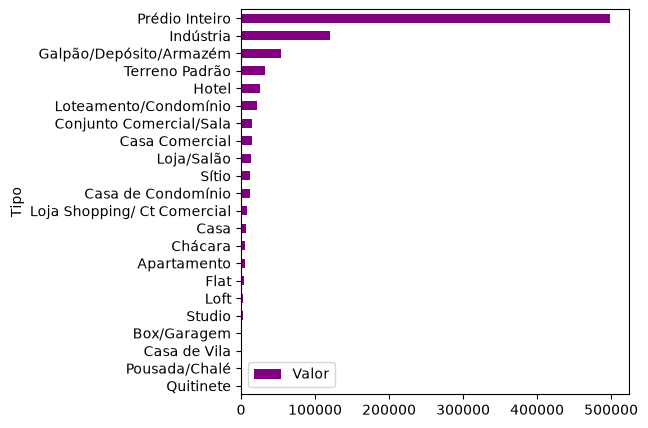

In [114]:
df_preco_tipo.plot(
    kind='barh',
    figsize=(5  ,5),
    color='purple'
);

## Removendo os imóveis comerciais

In [115]:
dados.Tipo.unique()

<ArrowStringArray>
[                  'Quitinete',                        'Casa',
     'Conjunto Comercial/Sala',                 'Apartamento',
          'Casa de Condomínio',              'Prédio Inteiro',
                        'Flat',                  'Loja/Salão',
     'Galpão/Depósito/Armazém',              'Casa Comercial',
                'Casa de Vila',              'Terreno Padrão',
                 'Box/Garagem',                        'Loft',
 'Loja Shopping/ Ct Comercial',                     'Chácara',
       'Loteamento/Condomínio',                       'Sítio',
               'Pousada/Chalé',                      'Studio',
                       'Hotel',                   'Indústria']
Length: 22, dtype: str

In [116]:
imoveis_comerciais = ['Conjunto Comercial/Sala', 

                      'Prédio Inteiro', 'Loja/Salão', 

                      'Galpão/Depósito/Armazém', 

                      'Casa Comercial', 'Terreno Padrão',

                      'Loja Shopping/ Ct Comercial',

                      'Box/Garagem', 'Chácara',

                      'Loteamento/Condomínio', 'Sítio',

                      'Pousada/Chalé', 'Hotel', 'Indústria']

In [117]:
dados.query('@imoveis_comerciais in Tipo')


,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
9,Conjunto Comercial/Sala,Centro,0,3,0,695,35000.0,19193.0,3030.0
16,Prédio Inteiro,Botafogo,0,0,0,536,28000.0,NaN,3563.0
26,Conjunto Comercial/Sala,São Cristóvão,0,1,0,25,1100.0,600.0,NaN
29,Loja/Salão,Campo Grande,0,1,0,35,1300.0,950.0,NaN
...,...,...,...,...,...,...,...,...,...
32942,Conjunto Comercial/Sala,Barra da Tijuca,0,1,0,55,2000.0,1096.0,NaN
32946,Conjunto Comercial/Sala,Centro,0,0,0,140,4000.0,1412.0,496.0
32948,Conjunto Comercial/Sala,Centro,0,0,0,32,600.0,1035.0,83.0
32954,Box/Garagem,Centro,0,0,0,755,14000.0,NaN,NaN


In [118]:
df = dados.query('@imoveis_comerciais not in Tipo')
df.Bairro.unique()

<ArrowStringArray>
[         'Copacabana',     'Jardim Botânico',              'Centro',
        'Higienópolis',        'Vista Alegre',            'Cachambi',
     'Barra da Tijuca',               'Ramos',              'Grajaú',
 'Lins de Vasconcelos',
 ...
                'Tauá',             'Ribeira',    'Magalhães Bastos',
              'Cacuia',           'Bancários',          'Cavalcanti',
        'Rio da Prata',       'Cidade Jardim',         'Coelho Neto',
             'Grumari']
Length: 154, dtype: str

In [119]:
df.Tipo.unique()

<ArrowStringArray>
[         'Quitinete',               'Casa',        'Apartamento',
 'Casa de Condomínio',               'Flat',       'Casa de Vila',
               'Loft',             'Studio']
Length: 8, dtype: str

In [120]:
df_preco_tipo = df.groupby('Tipo')[['Valor']].mean().sort_values('Valor')


<Axes: ylabel='Tipo'>

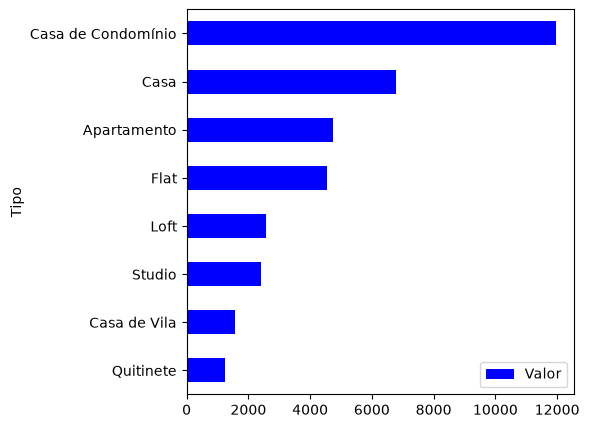

In [121]:
df_preco_tipo.plot(
    kind='barh',
    figsize=(5,5),
    color='Blue'
)

## Qual o percentual de cada tipo de imóvel na nossa base de dados?

In [122]:
df.Tipo.value_counts(normalize=True).to_frame().sort_values('Tipo')

,proportion
Tipo,
Apartamento,0.845139
Casa,0.041842
Casa de Condomínio,0.043096
Casa de Vila,0.010774
Flat,0.020596
Loft,0.002207
Quitinete,0.036173
Studio,0.000173


<Axes: xlabel='Tipo', ylabel='Percentual'>

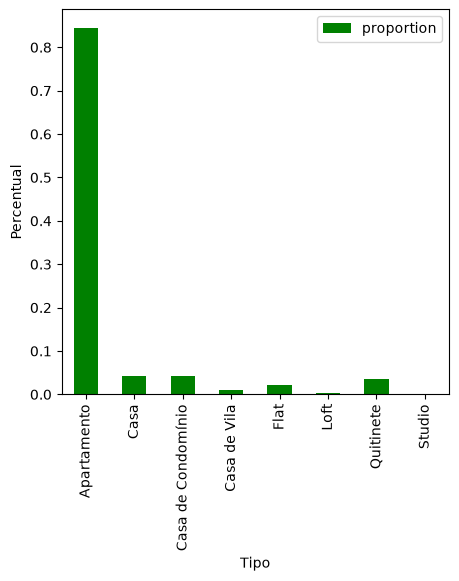

In [123]:

df_percentual_tipo = df.Tipo.value_counts(normalize=tuple).to_frame().sort_values('Tipo')
df_percentual_tipo.plot(
    kind='bar',
    figsize=(5,5),
    color='green',
    xlabel='Tipo',
    ylabel='Percentual'
)

### **Selecionando apenas os imóveis do tipo apartamento**

In [124]:
df.query('Tipo == "Apartamento"')

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
32951,Apartamento,Vila Valqueire,2,0,0,52,1000.0,550.0,NaN
32953,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


In [125]:
df = df.query('Tipo == "Apartamento"')
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN


In [126]:
df_exemplo = df.rename(
    {
        'Tipo':'strTipo',
        'Bairro':'strBairro',
        'Quartos':'intQuartos',
        'Vagas':'intVagas',
        'Suites':'intSuites',
        'Area':'intArea',
        'Valor':'decValor',
        'Condominio':'decCondominio',
        'IPTU':'decIPTU'
        
    }, inplace=True
)

df_exemplo

# Tratando e filtrando os dados

## Lidando com dados nulos

## Removendo registros

## Filtros

### **1. Apartamentos que possuem `1 quarto` e `aluguel menor que 1200`**



### **2. `Apartamentos` que possuem pelo menos `2 quartos`, `aluguel menor que 3000` e `area maior que 70`**

## Salvando os dados

# Manipulando os dados

## Criando colunas numéricas

## Criando colunas categóricas